In [1]:
import sys; sys.path.insert(0, '..')
import pandas as pd
import numpy as np

from src.ingest.rama import load_wide, to_long

long = to_long(load_wide('../data/raw/2025O3.xls'), 'O3')

# pivot: convierte formato largo a matriz horas x estaciones
matriz = long.pivot(index='timestamp', columns='station', values='value')

# Excluir las que no operaron en 2025: no aportan señal ni ausencia informativa
vacias = matriz.columns[matriz.notna().sum() == 0].tolist()
print(f"Sin dato en todo 2025: {vacias}")
matriz = matriz.drop(columns=vacias)

n_est = matriz.shape[1]
print(f"Matriz resultante: {matriz.shape[0]} horas x {n_est} estaciones\n")

faltantes = matriz.isna().sum(axis=1)

print("Estaciones faltantes por hora:")
print(f"  media:    {faltantes.mean():.1f} de {n_est}")
print(f"  mediana:  {faltantes.median():.0f}")
print(f"  mínimo:   {faltantes.min()}")
print(f"  máximo:   {faltantes.max()}")
print(f"\n  % de información disponible en la hora típica: "
      f"{(1 - faltantes.median()/n_est)*100:.1f}%")

print("\nDistribución (% de horas con N faltantes):")
dist = (faltantes.value_counts().sort_index() / len(matriz) * 100).round(2)
print(dist.head(20).to_string())

Sin dato en todo 2025: ['COY', 'SFE', 'SJA']
Matriz resultante: 8760 horas x 33 estaciones

Estaciones faltantes por hora:
  media:    8.0 de 33
  mediana:  7
  mínimo:   0
  máximo:   33

  % de información disponible en la hora típica: 78.8%

Distribución (% de horas con N faltantes):
0      0.43
1      3.13
2      5.06
3      6.47
4      9.35
5      7.50
6     13.44
7     11.79
8      9.09
9      6.13
10     3.85
11     1.74
12     3.41
13     4.84
14     4.08
15     2.76
16     3.32
17     1.10
18     0.27
19     0.10


In [2]:
# 1. ¿Cuántas horas son catastróficas?
for umbral in [15, 20, 25, 30, 33]:
    n = (faltantes >= umbral).sum()
    print(f"Horas con >={umbral} faltantes: {n:>4} ({n/len(matriz)*100:.2f}%)")

Horas con >=15 faltantes:  850 (9.70%)
Horas con >=20 faltantes:  188 (2.15%)
Horas con >=25 faltantes:  183 (2.09%)
Horas con >=30 faltantes:  132 (1.51%)
Horas con >=33 faltantes:   18 (0.21%)


In [3]:
# 2. ¿Se concentran en alguna hora del día?
df_f = pd.DataFrame({'faltantes': faltantes})
df_f['hora'] = df_f.index.hour
print("\nFaltantes promedio por hora del día:")
print(df_f.groupby('hora')['faltantes'].mean().round(1).to_string())


Faltantes promedio por hora del día:
hora
0     11.0
1     11.0
2     11.0
3      7.3
4      7.2
5      7.3
6      7.3
7      7.4
8      7.4
9      7.5
10     7.8
11     8.1
12     8.3
13     8.1
14     8.0
15     7.8
16     7.7
17     7.6
18     7.5
19     7.5
20     7.4
21     7.4
22     7.4
23     7.6


In [4]:
# 3. ¿Son eventos aislados o bloques largos?
critico = (faltantes >= 25).astype(int)
grupos = (critico != critico.shift()).cumsum()
rachas = critico.groupby(grupos).sum()
rachas = rachas[rachas > 0]
print(f"\nEventos con >=25 faltantes: {len(rachas)}")
print(f"Duración: media {rachas.mean():.1f} h, máx {rachas.max()} h")


Eventos con >=25 faltantes: 61
Duración: media 3.0 h, máx 3 h


In [5]:
from src.detect.windows import construir_ventanas

# Split cronologico ANTES de normalizar
corte = int(len(matriz) * 0.8)
mat_tr, mat_te = matriz.iloc[:corte], matriz.iloc[corte:]

Xtr, ytr, ts_tr, mu, sigma = construir_ventanas(mat_tr, 'CCA', ventana=24)
Xte, yte, ts_te, _, _ = construir_ventanas(mat_te, 'CCA', ventana=24,
                                           mu=mu, sigma=sigma)

print(f"Entrenamiento: {Xtr.shape}   y: {ytr.shape}")
print(f"Prueba:        {Xte.shape}   y: {yte.shape}")
print(f"\nRango temporal train: {ts_tr[0]} -> {ts_tr[-1]}")
print(f"Rango temporal test:  {ts_te[0]} -> {ts_te[-1]}")
print(f"\nFraccion de datos reales en X (media de la mascara): "
      f"{Xtr[:, :, 32:].mean():.3f}")

Entrenamiento: (6764, 24, 64)   y: (6764,)
Prueba:        (1684, 24, 64)   y: (1684,)

Rango temporal train: 2025-01-02T00:00:00.000000 -> 2025-10-19T23:00:00.000000
Rango temporal test:  2025-10-21T00:00:00.000000 -> 2025-12-31T23:00:00.000000

Fraccion de datos reales en X (media de la mascara): 0.786


In [6]:
from src.detect.lstm import construir_modelo, entrenar

modelo = construir_modelo(ventana=24, n_features=Xtr.shape[2])
modelo.summary()

I0000 00:00:1789339669.690609    6486 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789339669.695488    6486 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789339670.162299    6486 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789339671.801702    6486 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,137 (137.25 KB)

 Trainable params: 35,137 (137.25 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
historia = entrenar(modelo, Xtr, ytr, val_frac=0.2, epocas=50)

Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 1349.3773 - mae: 26.5070 - val_loss: 567.3697 - val_mae: 16.5857
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 388.6155 - mae: 13.6628 - val_loss: 221.4911 - val_mae: 10.4839
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 165.1158 - mae: 9.3459 - val_loss: 182.4244 - val_mae: 9.5381
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 118.3056 - mae: 8.0907 - val_loss: 166.6380 - val_mae: 8.9479
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 97.9722 - mae: 7.4954 - val_loss: 159.4268 - val_mae: 8.7268
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 86.8979 - mae: 7.0473 - val_loss: 149.4855 - val_mae: 8.4060
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 82.8253 - mae: 6.8916 - val_loss: 142.4599 - val_mae: 8.2681
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 76.4464 - mae: 6.6283 - val_loss: 145.3495 - val_mae: 8.2716
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 

## Comparacion entre datos predecidos y datos reales

In [8]:
import matplotlib.pyplot as plt

pred = modelo.predict(Xte, verbose=0).flatten()
residuo = yte - pred

df_ev = pd.DataFrame({
    'timestamp': ts_te,
    'real': yte,
    'predicho': pred,
    'residuo': residuo,
})
df_ev['hora'] = pd.to_datetime(df_ev.timestamp).dt.hour

print(f"MAE  test: {np.abs(residuo).mean():.2f} ppb")
print(f"Sesgo:     {residuo.mean():+.2f} ppb")
print(f"σ residuo: {residuo.std():.2f} ppb")
print(f"\nPercentiles del |residuo|:")
for p in [50, 75, 90, 95, 99]:
    print(f"  p{p}: {np.percentile(np.abs(residuo), p):6.2f} ppb")

MAE  test: 8.39 ppb
Sesgo:     +2.80 ppb
σ residuo: 10.98 ppb

Percentiles del |residuo|:
  p50:   6.48 ppb
  p75:  11.06 ppb
  p90:  17.26 ppb
  p95:  23.30 ppb
  p99:  38.29 ppb


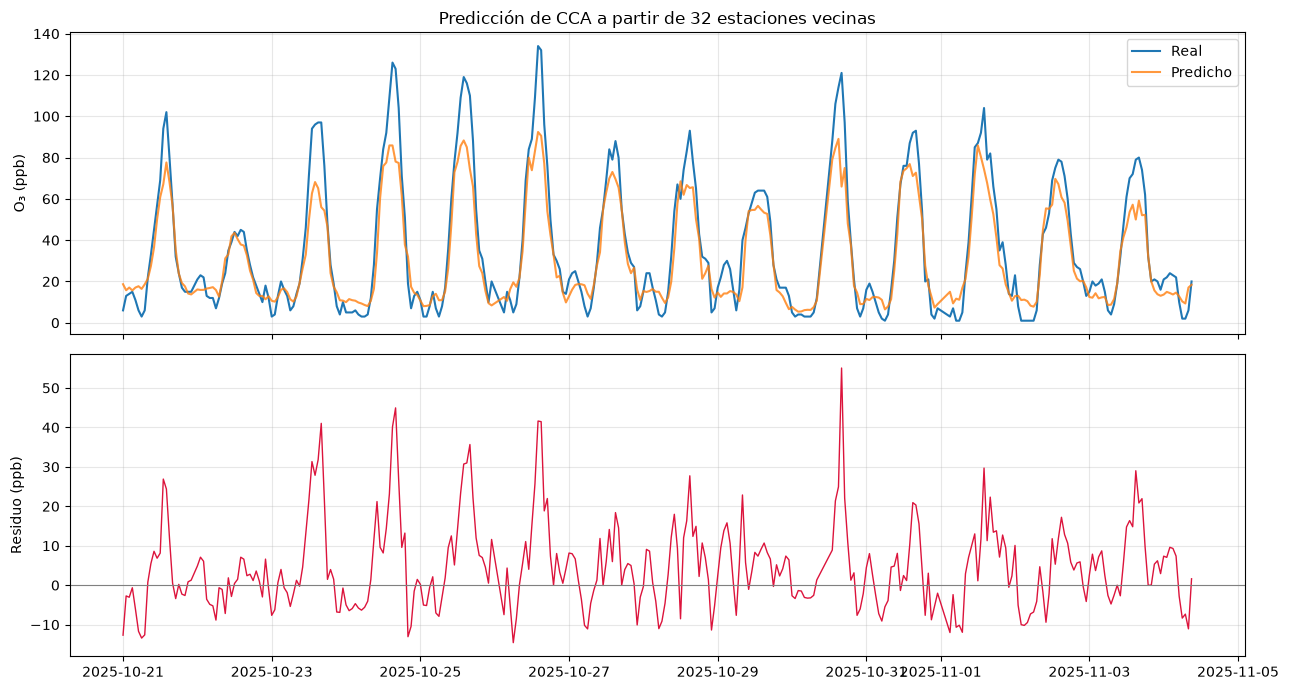

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

n = 336   # dos semanas
ax1.plot(df_ev.timestamp[:n], df_ev.real[:n], lw=1.5, label='Real')
ax1.plot(df_ev.timestamp[:n], df_ev.predicho[:n], lw=1.5, alpha=0.8,
         label='Predicho')
ax1.set_ylabel('O₃ (ppb)')
ax1.legend()
ax1.grid(alpha=0.3)
ax1.set_title('Predicción de CCA a partir de 32 estaciones vecinas')

ax2.plot(df_ev.timestamp[:n], df_ev.residuo[:n], lw=1, color='crimson')
ax2.axhline(0, c='gray', lw=0.8)
ax2.set_ylabel('Residuo (ppb)')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/img/lstm_prediccion.png', dpi=150)
plt.show()

In [10]:
por_hora = df_ev.groupby('hora').agg(
    real_media=('real', 'mean'),
    mae=('residuo', lambda r: r.abs().mean()),
    sesgo=('residuo', 'mean'),
).round(2)
print(por_hora.to_string())

      real_media        mae  sesgo
hora                              
0      11.380000   5.750000  -1.07
1      11.630000   5.570000  -1.15
2      11.130000   5.440000  -1.37
3       9.760000   5.980000  -2.96
4       8.830000   5.380000  -2.98
5       6.680000   6.780000  -5.83
6       4.170000   8.180000  -7.76
7       4.850000   7.830000  -7.32
8      11.620000   6.200000  -4.40
9      24.590000   3.810000   0.93
10     41.830002   7.280000   5.47
11     58.509998   7.210000   6.34
12     71.209999   8.410000   7.61
13     80.989998  12.610000  11.88
14     84.489998  14.860000  12.93
15     83.750000  17.660000  15.68
16     77.959999  20.030001  18.68
17     63.860001  14.310000  13.15
18     39.919998   6.960000   1.80
19     27.219999   7.910000   5.17
20     20.330000   6.270000   1.13
21     16.100000   5.520000   0.36
22     13.470000   5.010000   0.25
23     11.600000   5.140000  -0.81


In [11]:
import importlib
import src.detect.windows
importlib.reload(src.detect.windows)
from src.detect.windows import construir_ventanas

Xtr, ytr, ts_tr, mu, sigma = construir_ventanas(mat_tr, 'CCA', ventana=24)
Xte, yte, ts_te, _, _ = construir_ventanas(mat_te, 'CCA', ventana=24,
                                           mu=mu, sigma=sigma)

print(f"Nueva forma: {Xtr.shape}")   # debe ser (6764, 24, 66)

modelo2 = construir_modelo(ventana=24, n_features=Xtr.shape[2])
historia2 = entrenar(modelo2, Xtr, ytr, val_frac=0.2, epocas=50, verbose=0)

pred2 = modelo2.predict(Xte, verbose=0).flatten()
res2 = yte - pred2

df2 = pd.DataFrame({'timestamp': ts_te, 'real': yte,
                    'predicho': pred2, 'residuo': res2})
df2['hora'] = pd.to_datetime(df2.timestamp).dt.hour

print(f"\nMAE test: {np.abs(res2).mean():.2f} ppb   (antes 8.39)")
print(f"Sesgo:    {res2.mean():+.2f} ppb   (antes +2.80)")

comp = pd.DataFrame({
    'real_media': df2.groupby('hora').real.mean().round(1),
    'mae_antes': df_ev.groupby('hora').residuo.apply(lambda r: r.abs().mean()).round(2),
    'mae_ahora': df2.groupby('hora').residuo.apply(lambda r: r.abs().mean()).round(2),
    'sesgo_ahora': df2.groupby('hora').residuo.mean().round(2),
})
print(comp.to_string())

Nueva forma: (6764, 24, 66)

MAE test: 7.62 ppb   (antes 8.39)
Sesgo:    +1.84 ppb   (antes +2.80)
      real_media  mae_antes  mae_ahora  sesgo_ahora
hora                                               
0      11.400000   5.750000   6.310000         0.12
1      11.600000   5.570000   5.550000         0.05
2      11.100000   5.440000   4.680000        -0.23
3       9.800000   5.980000   4.600000        -1.00
4       8.800000   5.380000   4.100000        -1.05
5       6.700000   6.780000   4.690000        -3.92
6       4.200000   8.180000   6.920000        -6.68
7       4.800000   7.830000   7.860000        -7.61
8      11.600000   6.200000   7.230000        -6.07
9      24.600000   3.810000   4.740000        -2.18
10     41.799999   7.280000   5.700000         1.05
11     58.500000   7.210000   6.290000         1.31
12     71.199997   8.410000   6.790000         2.35
13     81.000000  12.610000   9.420000         7.66
14     84.500000  14.860000  12.880000        10.21
15     83.800003 

In [12]:
import importlib, src.detect.windows
importlib.reload(src.detect.windows)
from src.detect.windows import construir_ventanas, perfil_horario

# Perfil SOLO del entrenamiento
perf = perfil_horario(mat_tr['CCA'])
print("Perfil horario de CCA (train):")
print(perf.round(1).to_string())

Xtr3, ytr3, ts_tr3, Btr3, mu3, sg3 = construir_ventanas(
    mat_tr, 'CCA', ventana=24, perfil=perf, predecir_desviacion=True)
Xte3, yte3, ts_te3, Bte3, _, _ = construir_ventanas(
    mat_te, 'CCA', ventana=24, mu=mu3, sigma=sg3,
    perfil=perf, predecir_desviacion=True)

print(f"\ny ahora es desviacion: media {ytr3.mean():+.2f}, "
      f"rango [{ytr3.min():.1f}, {ytr3.max():.1f}]")

modelo3 = construir_modelo(ventana=24, n_features=Xtr3.shape[2])
historia3 = entrenar(modelo3, Xtr3, ytr3, val_frac=0.2, epocas=60, verbose=0)

# Reconstruir el valor absoluto
desv_pred = modelo3.predict(Xte3, verbose=0).flatten()
pred3 = Bte3 + desv_pred
real3 = Bte3 + yte3
res3 = real3 - pred3

print(f"\nMAE test: {np.abs(res3).mean():.2f} ppb   "
      f"(v1: 8.39, v2: 7.62)")
print(f"Sesgo:    {res3.mean():+.2f} ppb")

df3 = pd.DataFrame({'timestamp': ts_te3, 'real': real3,
                    'predicho': pred3, 'residuo': res3})
df3['hora'] = pd.to_datetime(df3.timestamp).dt.hour

comp = pd.DataFrame({
    'real': df3.groupby('hora').real.mean().round(1),
    'mae_v2': df2.groupby('hora').residuo.apply(lambda r: r.abs().mean()).round(2),
    'mae_v3': df3.groupby('hora').residuo.apply(lambda r: r.abs().mean()).round(2),
    'sesgo_v3': df3.groupby('hora').residuo.mean().round(2),
})
print(comp.to_string())

Perfil horario de CCA (train):
timestamp
0     17.2
1     16.4
2     15.9
3     14.4
4     13.3
5     10.7
6      6.7
7      8.3
8     16.9
9     29.8
10    45.3
11    60.9
12    73.5
13    81.6
14    82.1
15    76.4
16    67.4
17    55.8
18    43.7
19    34.2
20    26.8
21    21.6
22    18.7
23    17.6

y ahora es desviacion: media -0.03, rango [-75.1, 81.6]

MAE test: 7.92 ppb   (v1: 8.39, v2: 7.62)
Sesgo:    +3.62 ppb
           real     mae_v2  mae_v3  sesgo_v3
hora                                        
0     11.400000   6.310000    6.21     -1.45
1     11.600000   5.550000    6.13     -1.05
2     11.100000   4.680000    5.50     -1.30
3      9.800000   4.600000    5.50     -1.92
4      8.800000   4.100000    4.48     -1.13
5      6.700000   4.690000    4.00     -1.74
6      4.200000   6.920000    3.33     -0.20
7      4.800000   7.860000    2.52     -0.83
8     11.600000   7.230000    4.89     -1.68
9     24.600000   4.740000    5.76      1.66
10    41.799999   5.700000   10.03 

### Intento 3: perfil horario adaptativo

**Diagnóstico previo.** El perfil calculado sobre el conjunto de entrenamiento
(ene–oct) no describe el periodo de prueba (nov–dic):

| Hora | Perfil ene–oct | Real nov–dic | Desfase |
|---|---|---|---|
| 0 | 17.2 | 11.4 | −5.8 |
| 7 | 8.3 | 4.8 | −3.5 |
| 16 | 67.4 | 78.0 | **+10.6** |
| 17 | 55.8 | 63.9 | +8.1 |

El error no proviene del modelo sino de la línea base: aunque predijera la
desviación con exactitud, el valor reconstruido arrastraría el desfase del
perfil.

**Propuesta.** Sustituir el promedio anual fijo por una media móvil por hora de
los últimos N días. La línea base sigue al régimen vigente en lugar de
representar un promedio que no corresponde a ningún periodo concreto.

**Justificación operativa.** Es lo que haría un sistema desplegado: recalibrar
continuamente contra el comportamiento reciente. Un perfil fijo calculado en
enero tendría el mismo desfase en abril, con split cronológico o sin él.

**Criterio de éxito.** Que el sesgo en las horas 15–17 descienda de +13 a +15
ppb hasta ±3 ppb. Sin esa corrección, la evaluación sobre datos atacados no es
interpretable: un residuo de 17 ppb sin ataque enmascara por completo un ataque
del bit 4 (16 ppb).

**Parámetro a barrer.** La ventana N (7, 14, 30 días) es un compromiso: muy
corta sigue el ruido diario, muy larga no reacciona al cambio estacional.

In [19]:
import importlib, src.detect.windows
importlib.reload(src.detect.windows)
from src.detect.windows import construir_ventanas, perfil_adaptativo

# El perfil se calcula sobre la serie COMPLETA de forma causal:
# cada punto usa solo su propio pasado, por lo que no hay fuga.
serie_cca = matriz['CCA']
perf_ad = perfil_adaptativo(serie_cca, dias=14)

corte = int(len(matriz) * 0.8)
perf_tr, perf_te = perf_ad.iloc[:corte], perf_ad.iloc[corte:]

Xtr4, ytr4, ts_tr4, Btr4, mu4, sg4 = construir_ventanas(
    mat_tr, 'CCA', ventana=24, perfil=perf_tr, predecir_desviacion=True)
Xte4, yte4, ts_te4, Bte4, _, _ = construir_ventanas(
    mat_te, 'CCA', ventana=24, mu=mu4, sigma=sg4,
    perfil=perf_te, predecir_desviacion=True)

modelo4 = construir_modelo(ventana=24, n_features=Xtr4.shape[2])
historia4 = entrenar(modelo4, Xtr4, ytr4, val_frac=0.2, epocas=60, verbose=0)

pred4 = Bte4 + modelo4.predict(Xte4, verbose=0).flatten()
real4 = Bte4 + yte4
res4 = real4 - pred4

print(f"MAE test: {np.abs(res4).mean():.2f} ppb   "
      f"(v1 8.39 | v2 7.62 | v3 7.92)")
print(f"Sesgo:    {res4.mean():+.2f} ppb")

df4 = pd.DataFrame({'timestamp': ts_te4, 'real': real4,
                    'predicho': pred4, 'residuo': res4})
df4['hora'] = pd.to_datetime(df4.timestamp).dt.hour

comp = pd.DataFrame({
    'real': df4.groupby('hora').real.mean().round(1),
    'mae_v2': df2.groupby('hora').residuo.apply(lambda r: r.abs().mean()).round(2),
    'mae_v3': df3.groupby('hora').residuo.apply(lambda r: r.abs().mean()).round(2),
    'mae_v4': df4.groupby('hora').residuo.apply(lambda r: r.abs().mean()).round(2),
    'sesgo_v4': df4.groupby('hora').residuo.mean().round(2),
})
print(comp.to_string())

MAE test: 9.35 ppb   (v1 8.39 | v2 7.62 | v3 7.92)
Sesgo:    +0.18 ppb
           real     mae_v2  mae_v3     mae_v4  sesgo_v4
hora                                                   
0     11.400000   6.310000    6.21   7.280000      2.40
1     11.600000   5.550000    6.13   7.730000      1.74
2     11.100000   4.680000    5.50   7.200000      1.06
3      9.800000   4.600000    5.50   7.000000     -0.39
4      8.800000   4.100000    4.48   5.990000      0.05
5      6.700000   4.690000    4.00   5.620000      0.01
6      4.200000   6.920000    3.33   4.170000      0.36
7      4.800000   7.860000    2.52   3.880000      0.87
8     11.600000   7.230000    4.89   5.100000      1.04
9     24.600000   4.740000    5.76   6.290000      1.51
10    41.799999   5.700000   10.03   8.530000      0.48
11    58.500000   6.290000   11.15  10.730000     -1.99
12    71.199997   6.790000   10.88  11.600000     -4.19
13    81.000000   9.420000   12.44  13.120000     -4.79
14    84.500000  12.880000   14.2

In [15]:
print(f"Perfil adaptativo: {perf_ad.isna().sum()} NaN de {len(perf_ad)} "
      f"({perf_ad.isna().mean()*100:.1f}%)")
print(f"Primeros valores válidos: {perf_ad.first_valid_index()}")
print(f"\nBte4: {np.isnan(Bte4).sum()} NaN de {len(Bte4)}")
print(f"ytr4: {np.isnan(ytr4).sum()} NaN de {len(ytr4)}")

Perfil adaptativo: 72 NaN de 8760 (0.8%)
Primeros valores válidos: 2025-01-04 00:00:00

Bte4: 0 NaN de 1684
ytr4: 48 NaN de 6764


In [18]:
import importlib
import src.detect.windows
importlib.reload(src.detect.windows)
from src.detect.windows import perfil_adaptativo, construir_ventanas, perfil_horario

In [20]:
for dias in [7, 14, 21, 30, 45]:
    perf = perfil_adaptativo(serie_cca, dias=dias)
    pt, pv = perf.iloc[:corte], perf.iloc[corte:]
    
    Xa, ya, tsa, Ba, mua, sga = construir_ventanas(
        mat_tr, 'CCA', ventana=24, perfil=pt, predecir_desviacion=True)
    Xb, yb, tsb, Bb, _, _ = construir_ventanas(
        mat_te, 'CCA', ventana=24, mu=mua, sigma=sga,
        perfil=pv, predecir_desviacion=True)
    
    m = construir_modelo(24, Xa.shape[2])
    entrenar(m, Xa, ya, epocas=40, verbose=0)
    
    r = (Bb + yb) - (Bb + m.predict(Xb, verbose=0).flatten())
    print(f"dias={dias:>2}:  MAE {np.abs(r).mean():5.2f}  "
          f"sesgo {r.mean():+5.2f}  σ {r.std():5.2f}")

dias= 7:  MAE  9.77  sesgo +0.96  σ 13.42
dias=14:  MAE  9.13  sesgo -1.19  σ 12.77
dias=21:  MAE 10.31  sesgo +2.00  σ 13.93
dias=30:  MAE  9.20  sesgo +1.75  σ 12.32
dias=45:  MAE  9.13  sesgo +3.30  σ 12.00


# Qué pasó con el modelo, explicado desde cero

Esta celda documenta el proceso de los cuatro intentos, los conceptos
involucrados y por qué la versión con peor número es la que sirve.

---

## 1. Qué está haciendo el modelo

La idea, en una frase:

> Usando lo que midieron las otras 32 estaciones de la ciudad durante las
> últimas 24 horas, adivina cuánto ozono está midiendo CCA en este momento.

**CCA no aparece en la entrada.** El modelo nunca la ve. Tiene que deducirla
mirando a sus vecinas.

Por ejemplo, el 15 de marzo a las 14:00:

```
Lo que el modelo recibe:
   qué midieron ACO, AJM, TLA, PED... (32 estaciones)
   desde el 14 a las 14:00 hasta el 15 a las 13:00

Lo que tiene que responder:
   ¿cuánto midió CCA el 15 a las 14:00?

La respuesta correcta (que el modelo no ve):
   84 ppb
```

### Por qué esto sirve para detectar ataques

Si el atacante manipula la lectura de CCA, **las vecinas siguen diciendo la
verdad**. El modelo predice lo que CCA *debería* estar midiendo, y si el valor
que llega es muy distinto, algo pasó.

```
Modelo predice (según las vecinas):   84 ppb
Valor que llega al servidor:         116 ppb
                                     ───────
Diferencia:                           32 ppb   ← sospechoso
```

Esa diferencia se llama **residuo**, y es todo el detector.

---

## 2. Los conceptos, con ejemplos

### Residuo

La diferencia entre lo que pasó de verdad y lo que el modelo predijo.

```
residuo = valor_real − valor_predicho
```

Si CCA midió 84 y el modelo predijo 80, el residuo es **+4**.
Si CCA midió 84 y el modelo predijo 90, el residuo es **−6**.

El signo importa: positivo significa que el modelo se quedó corto; negativo,
que se pasó.

### MAE — error absoluto medio

*Mean Absolute Error*. Responde: **¿de cuánto se equivoca el modelo, en
promedio?**

«Absoluto» significa que se ignora el signo: un error de −6 cuenta igual que uno
de +6. Solo importa el tamaño.

Ejemplo con cinco predicciones:

| Real | Predicho | Residuo | Sin signo |
|---|---|---|---|
| 84 | 80 | +4 | 4 |
| 62 | 70 | −8 | 8 |
| 15 | 13 | +2 | 2 |
| 90 | 85 | +5 | 5 |
| 45 | 51 | −6 | 6 |

```
MAE = (4 + 8 + 2 + 5 + 6) / 5 = 5 ppb
```

**El modelo se equivoca 5 ppb en promedio.** Se lee en las mismas unidades que
los datos, por eso es la métrica más interpretable.

### Sesgo

**¿El modelo se equivoca siempre hacia el mismo lado?**

Es el promedio de los residuos, pero **conservando el signo**:

```
Sesgo = (+4 − 8 + 2 + 5 − 6) / 5 = −0.6 ppb
```

Casi cero: se equivoca a veces hacia arriba, a veces hacia abajo, y se
compensan. Eso es lo deseable.

Ahora compara con este caso:

| Real | Predicho | Residuo |
|---|---|---|
| 84 | 70 | +14 |
| 90 | 75 | +15 |
| 78 | 62 | +16 |
| 82 | 69 | +13 |

```
MAE   = 14.5 ppb
Sesgo = +14.5 ppb    ← idéntico al MAE
```

**Todos los errores van en la misma dirección.** El modelo siempre predice de
menos. Eso no es ruido, es un defecto sistemático.

**Regla práctica:** cuando el MAE y el sesgo son casi iguales, el modelo tiene
un problema estructural. Cuando el sesgo está cerca de cero, el error es ruido
aleatorio.

### σ (sigma) — desviación estándar

La letra griega sigma. Mide **qué tanto se dispersan los valores alrededor de su
promedio**.

Ejemplo con dos modelos, ambos con sesgo cero:

```
Modelo A — residuos:   +2, −1, +1, −2, 0
Modelo B — residuos:  +30, −28, +25, −27, 0
```

Los dos promedian cero. Pero el A se equivoca poco y el B muchísimo.

σ captura esa diferencia: σ del A ≈ 1.6, σ del B ≈ 27.

**σ pequeña = predicciones consistentes. σ grande = predicciones erráticas.**

Para el detector, σ es lo que importa: es el «ruido de fondo» que un ataque
tiene que superar para notarse.

---

## 3. El problema que apareció

El primer modelo dio un MAE de 8.39 ppb. Suena aceptable. Pero al mirar hora por
hora:

| Hora | O₃ real | MAE | Sesgo |
|---|---|---|---|
| 4:00 | 8.8 | 5.4 | −3.0 |
| 12:00 | 71.2 | 8.4 | +7.6 |
| **16:00** | **78.0** | **20.0** | **+18.7** |
| 22:00 | 13.5 | 5.0 | +0.2 |

A las 4 de la mañana se equivoca 5 ppb. **A las 4 de la tarde, 20 ppb.**

Y fíjate en las 16:00: MAE de 20.0 y sesgo de +18.7, prácticamente iguales.
Aplicando la regla de arriba, eso es un defecto sistemático.

### Qué significa «sesgo de +18.7»

El modelo **siempre predice de menos** a esa hora.

```
CCA midió 78 ppb  →  el modelo predijo 59
CCA midió 82 ppb  →  el modelo predijo 64
CCA midió 75 ppb  →  el modelo predijo 57
```

Nunca al revés. Se queda corto todas las veces.

### Por qué pasa: el modelo aplana la curva

El ozono tiene un ciclo diario muy marcado: casi nada de madrugada, mucho por la
tarde.

```
Real:      ___/‾‾‾‾\___     sube alto y baja
Predicho:  __/‾‾‾‾‾\__      sube a medias
```

El modelo aprende que «normalmente hay poco ozono» —lo cual es cierto el 77% del
tiempo— y por eso nunca se atreve a predecir los picos.

Es como un pronosticador que dice «mañana no llueve» todos los días. Acierta
casi siempre, y falla justo cuando importa.

### Por qué esto rompe el detector

El detector marca anomalía cuando el residuo es grande. Pero a las 16:00 el
residuo ya vale +18.7 **sin ningún ataque**.

```
Sin ataque a las 16:00:        residuo = +18.7
Con ataque del bit 4 (+16):    residuo = +34.7
```

Para no marcar todas las horas normales como ataques, el umbral tendría que
estar por encima de 18.7. Y entonces el ataque de 16 ppb apenas asoma.

**Y las 15:00–17:00 son precisamente la ventana donde el ataque es más
efectivo.** El detector estaría ciego justo donde más se necesita.

---

## 4. Los cuatro intentos

### v1 — Modelo base

Solo las 32 vecinas y su máscara de validez.

```
MAE: 8.39    Sesgo a las 16:00: +18.68
```

Funciona en general, pero aplana el pico.

### v2 — Añadir la hora del día

Se le dice al modelo qué hora es, codificada como seno y coseno para que las
23:00 y las 00:00 queden juntas (son consecutivas, no opuestas).

Razón física: el ozono se forma con la luz solar, así que depende directamente
de la hora.

```
MAE: 7.62 (mejor)    Sesgo a las 16:00: +17.51 (casi igual)
```

**Mejoró el promedio, no el problema.** La ganancia se concentró en las horas de
madrugada, donde el ciclo es predecible. El pico siguió aplanado.

### v3 — Predecir la desviación en lugar del valor

En lugar de pedirle «predice 78 ppb», se le pide «predice cuánto se desvía de lo
normal para esta hora».

```
Lo normal a las 16:00 (promedio del año):  67.4 ppb
El modelo predice la desviación:           +10.6
Valor final:                       67.4 + 10.6 = 78 ppb
```

La idea: el ciclo diario se puede calcular con un promedio simple, sin
necesidad de una red neuronal. Al restarlo, el modelo solo aprende la parte
impredecible.

```
MAE: 7.92    Sesgo a las 16:00: +13.95
```

**Mejoró algo, pero no lo suficiente.** Y al investigar por qué, apareció la
causa real.

---

## 5. La causa real: el promedio estaba desactualizado

El modelo entrena con datos de enero a octubre y se evalúa en noviembre y
diciembre. El promedio por hora se calculó con los meses de entrenamiento.

Pero el ozono **no se comporta igual en todos los meses**:

| Hora | Promedio ene–oct | Real nov–dic | Desfase |
|---|---|---|---|
| 0:00 | 17.2 | 11.4 | −5.8 |
| 7:00 | 8.3 | 4.8 | −3.5 |
| **16:00** | **67.4** | **78.0** | **+10.6** |
| 17:00 | 55.8 | 63.9 | +8.1 |

En noviembre el pico de la tarde es **10 ppb más alto** que el promedio anual.

Entonces el modelo hace esto:

```
Base que se le da:              67.4 ppb   (promedio ene-oct)
Desviación que predice:         +10.6
Valor que produce:              78.0
Valor real de noviembre:        88.0
                                ──────
Error:                          −10.0      ← viene de la base, no del modelo
```

**Aunque predijera la desviación perfectamente, el resultado estaría 10 ppb
abajo**, porque la base de la que parte es de otra estación del año.

### Esto explica tres cosas que veníamos arrastrando

Lo que parecían problemas independientes son el mismo fenómeno:

1. El split estratificado daba peores resultados que el cronológico
2. La tasa de falsos positivos varía de 1.10% a 10.42% según el mes
3. El error en test (8.39) era peor que en validación (6.86)

**Todo es deriva estacional.** El comportamiento del ozono cambia a lo largo del
año, y cualquier referencia fija queda desactualizada.

---

## 6. v4 — Perfil adaptativo

En lugar de un promedio fijo de todo el año, se usa el promedio de **los últimos
14 días**.

```
Promedio fijo:        siempre 67.4 para las 16:00
Promedio adaptativo:  en marzo 61, en julio 70, en noviembre 76
```

La base se va actualizando sola. Es lo que haría un sistema real: recalibrarse
continuamente contra el comportamiento reciente.

**Detalle importante:** el promedio se calcula solo con datos **anteriores** al
momento que se predice. Si usara el día que está prediciendo, sería hacer
trampa.

### El resultado

| Hora | Sesgo v3 | Sesgo v4 |
|---|---|---|
| 15:00 | +12.88 | **−2.35** |
| 16:00 | +13.95 | **−1.72** |
| 17:00 | +10.84 | **−1.01** |
| Global | +3.62 | **+0.18** |

**El sesgo desapareció.** De +14 a menos de ±3.

Pero el MAE subió a 9.35 — el peor de los cuatro.

---

## 7. Por qué el peor número es el mejor modelo

Parece contradictorio, pero no lo es.

### El error cambió de naturaleza

**Antes (v3):** el modelo se equivocaba **siempre hacia abajo** a las 16:00.

```
residuos: +14, +15, +13, +16, +14, +15...
```

**Ahora (v4):** se equivoca en ambas direcciones.

```
residuos: +18, −17, +20, −16, +19, −18...
```

El MAE es parecido. Pero son situaciones completamente distintas para un
detector.

### Con sesgo sistemático, el detector no puede funcionar

```
v3, a las 16:00:
   Sin ataque:              residuo ≈ +14
   Con ataque del bit 4:    residuo ≈ +30

El umbral debe superar 14 para no marcar horas normales.
Solo quedan 16 puntos de margen.
```

### Con ruido aleatorio, sí puede

```
v4, a las 16:00:
   Sin ataque:              residuo ≈ 0, con dispersión de ±19
   Con ataque del bit 4:    residuo ≈ +16
   Con ataque del bit 5:    residuo ≈ +32
```

El umbral se pone alrededor de cero más unas cuantas desviaciones. Los ataques
grandes salen del rango normal.

**Un sesgo sistemático es ceguera. El ruido es falta de sensibilidad.** El
segundo se puede trabajar; el primero no.

---

## 8. El barrido de la ventana

Se probaron distintas longitudes para el promedio móvil:

| Días | MAE | Sesgo | σ |
|---|---|---|---|
| 7 | 9.77 | +0.96 | 13.42 |
| **14** | **9.13** | **−1.19** | **12.77** |
| 21 | 10.31 | +2.00 | 13.93 |
| 30 | 9.20 | +1.75 | 12.32 |
| 45 | 9.13 | +3.30 | 12.00 |

**El resultado es plano:** todo entre 9.1 y 10.3. La longitud de la ventana no
es el factor determinante.

Se observa un compromiso: ventanas largas dan σ menor (base más estable) pero
sesgo mayor (menos reactiva al cambio estacional).

**Se adopta 14 días**: mejor sesgo, σ competitiva.

---

## 9. Dónde queda el detector

Situación actual:

```
Ruido de fondo del modelo:   σ ≈ 13 ppb en general
                             σ ≈ 19 ppb en el pico vespertino
```

Un ataque tiene que superar ese ruido para notarse:

| Ataque | Δ | Contra σ=13 | Contra σ=19 (pico) |
|---|---|---|---|
| bit 3 | 8 ppb | 0.6× — invisible | 0.4× — invisible |
| bit 4 | 16 ppb | 1.2× — dudoso | 0.8× — invisible |
| bit 5 | 32 ppb | **2.5× — detectable** | 1.7× — dudoso |
| bit 6 | 64 ppb | **4.9× — claro** | **3.4× — claro** |

Los bits 5 y 6 —la zona explotable identificada en el notebook 06— deberían ser
detectables.

### Lo que falta

Evaluar sobre datos realmente atacados. Hasta ahora todo se ha hecho con datos
limpios: solo se ha medido qué tan bien predice el modelo, no si detecta.

**Ese es el siguiente paso**, y es el que dice si todo esto sirvió.

---

## 10. Resumen

| Versión | Cambio | MAE | Sesgo 16h | Veredicto |
|---|---|---|---|---|
| v1 | Base | 8.39 | +18.68 | Ciego en la tarde |
| v2 | + hora del día | 7.62 | +17.51 | Ciego en la tarde |
| v3 | Predice desviación | 7.92 | +13.95 | Ciego en la tarde |
| **v4** | **Perfil adaptativo** | 9.35 | **−1.72** | **Utilizable** |

**Se adopta v4** pese al MAE superior: es la única versión sin error
sistemático en la franja horaria de mayor relevancia para la detección.

### Hallazgo con valor propio

> Un detector de anomalías basado en predicción, desplegado sobre datos
> ambientales, requiere recalibración continua de su línea base. Un modelo
> entrenado sobre un régimen estacional degrada su desempeño al operar sobre
> otro, y esa degradación se concentra en las horas de mayor concentración —que
> son precisamente las de mayor relevancia para la detección.

## Evaluación de detección sobre datos atacados

Hasta aquí sólo se ha medido **qué tan bien predice** el modelo. Falta lo que
decide si sirve: **si detecta ataques**.

### Procedimiento

El modelo entrenado no se toca. Lo que cambia es la serie de CCA en el conjunto
de prueba: se le inyectan ataques de bit flipping usando el mismo generador del
notebook 05.


**Punto clave:** las vecinas **no** se atacan. Es la premisa del escenario
multiestación: el adversario compromete un solo nodo. Las demás siguen
reportando la verdad, y por eso el modelo predice el valor legítimo aunque el
recibido esté manipulado.

### El umbral

El modelo produce un residuo continuo. Convertirlo en decisión binaria requiere
un corte, y ese corte **no puede calibrarse sobre datos atacados** — en
producción no se dispone de esa información.

Se calibra sobre los residuos del conjunto de entrenamiento limpio, tomando
percentiles. El percentil 95 significa: «marco lo que está en el 5% más
anómalo de lo observado en operación normal».

Es la misma limitación que `contamination` en IsolationForest, con una ventaja:
se puede barrer el percentil y reportar la curva completa de recall frente a
falsos positivos, en lugar de un solo punto.

### Qué se espera

Con σ del residuo ≈ 13 ppb:

| Ataque | Δ | Δ/σ | Pronóstico |
|---|---|---|---|
| bit 3 | 8 | 0.6× | No detectable |
| bit 4 | 16 | 1.2× | Dudoso |
| bit 5 | 32 | 2.5× | Detectable |
| bit 6 | 64 | 4.9× | Claro |

La referencia es el detector de Capa 1 (notebook 06), que sobre lecturas
aisladas alcanzaba 41.4% de recall en el bit 5 y 72.9% en el bit 6.

In [21]:
from src.encoding.cayenne import encode_o3, decode_o3, flip_bit
from src.encoding.crypto import encrypt, decrypt
from src.attack.blind import APPSKEY, DEVADDR

def atacar_serie(valores, bit, tasa=0.05, seed=42):
    """Aplica bit flipping a una fraccion de las lecturas.

    Pasa por el cifrado real, no por un atajo aritmetico: el dataset
    depende de la implementacion que se defiende en la tesis.

    Devuelve (valores_atacados, etiquetas).
    """
    rng = np.random.default_rng(seed)
    v = valores.copy()
    etiq = np.zeros(len(v), dtype=int)

    for i in range(len(v)):
        if np.isnan(v[i]) or rng.random() >= tasa:
            continue
        trama = encrypt(encode_o3(int(v[i])), APPSKEY, DEVADDR, i + 1)
        atacada = flip_bit(trama, bit)
        v[i] = decode_o3(decrypt(atacada, APPSKEY, DEVADDR, i + 1))
        etiq[i] = 1

    return v, etiq

In [22]:
# Residuos del modelo sobre entrenamiento limpio
pred_tr = Btr4 + modelo4.predict(Xtr4, verbose=0).flatten()
real_tr = Btr4 + ytr4
res_tr = np.abs(real_tr - pred_tr)

umbrales = {p: np.percentile(res_tr, p) for p in [90, 95, 97, 99]}
print("Umbrales calibrados sobre entrenamiento limpio:")
for p, u in umbrales.items():
    print(f"  p{p}: {u:6.2f} ppb")

Umbrales calibrados sobre entrenamiento limpio:
  p90:  17.24 ppb
  p95:  22.57 ppb
  p97:  26.91 ppb
  p99:  36.60 ppb


In [23]:
from sklearn.metrics import precision_score, recall_score, fbeta_score

# Serie limpia de CCA en el periodo de prueba
cca_te = mat_te['CCA'].copy()

res_det = []
for bit in [3, 4, 5, 6, 7]:
    atacada, etiq = atacar_serie(cca_te.values, bit, tasa=0.05, seed=42)

    mat_atk = mat_te.copy()
    mat_atk['CCA'] = atacada          # solo CCA se ataca

    Xa, ya, tsa, Ba, _, _ = construir_ventanas(
        mat_atk, 'CCA', ventana=24, mu=mu4, sigma=sg4,
        perfil=perf_te, predecir_desviacion=True)

    # Alinear etiquetas con las ventanas construidas
    idx = pd.Series(etiq, index=cca_te.index).reindex(pd.to_datetime(tsa)).values

    recibido = Ba + ya
    predicho = Ba + modelo4.predict(Xa, verbose=0).flatten()
    residuo = np.abs(recibido - predicho)

    for p, u in umbrales.items():
        marcado = (residuo > u).astype(int)
        res_det.append({
            'bit': bit, 'delta_ppb': 2**bit, 'percentil': p,
            'umbral_ppb': round(u, 1),
            'recall_%': round(recall_score(idx, marcado, zero_division=0)*100, 1),
            'precision_%': round(precision_score(idx, marcado, zero_division=0)*100, 1),
            'f2_%': round(fbeta_score(idx, marcado, beta=2, zero_division=0)*100, 1),
            'fp': int(((marcado == 1) & (idx == 0)).sum()),
        })

det = pd.DataFrame(res_det)
det.to_csv('../results/deteccion_lstm.csv', index=False)

det.pivot_table(index=['bit', 'delta_ppb'], columns='percentil',
                values='recall_%')

,percentil,90,95,97,99
bit,delta_ppb,,,,
3,8,16.7,9.0,2.6,2.6
4,16,33.3,20.5,11.5,5.1
5,32,89.7,84.6,67.9,20.5
6,64,100.0,98.7,98.7,97.4
7,128,100.0,100.0,100.0,100.0


In [24]:
print(det[det.bit.isin([4, 5, 6])][
    ['bit', 'percentil', 'umbral_ppb', 'recall_%', 'precision_%', 'f2_%', 'fp']
].to_string(index=False))

 bit  percentil  umbral_ppb  recall_%  precision_%  f2_%  fp
   4         90   17.200001      33.3          9.4  22.0 252
   4         95   22.600000      20.5         10.9  17.4 131
   4         97   26.900000      11.5          9.8  11.1  83
   4         99   36.599998       5.1         10.0   5.7  36
   5         90   17.200001      89.7         21.7  55.2 252
   5         95   22.600000      84.6         33.5  64.8 131
   5         97   26.900000      67.9         39.0  59.2  83
   5         99   36.599998      20.5         30.8  22.0  36
   6         90   17.200001     100.0         23.6  60.7 252
   6         95   22.600000      98.7         37.0  74.0 131
   6         97   26.900000      98.7         48.1  81.6  83
   6         99   36.599998      97.4         67.9  89.6  36
